# Этап 1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Импорт библиотек

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter
from scipy import fft
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Считывание данных из подготовленного файла

In [13]:
data = pd.read_csv('data.csv', header=None, names=['t', 'a', 'klass'])
t_val = data['t'].values
a_val = data['a'].values
klass_val = data['klass'].values

Рисование графика (пока без цвета)

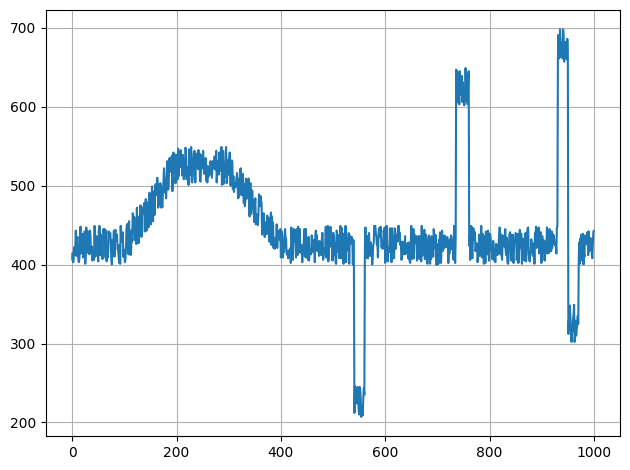

In [14]:
plt.plot(t_val, a_val, solid_capstyle='round')
plt.grid(True)
plt.tight_layout()
plt.show()

Считывание данных для обучение модели

In [15]:
train_data = pd.read_csv('train_data.csv', names=['t', 'a', 'klass'])

In [25]:
def extract_features(segment):
    """
    Извлекает ТОЛЬКО САМЫЕ ВАЖНЫЕ признаки из спектра Фурье.
    Минимальный набор для различения 4 классов.
    """
    N = len(segment)
    features = {}
    
    raw_centered = segment - np.mean(segment)
    yf_raw = fft.fft(raw_centered)
    spectrum_raw = np.abs(yf_raw[:N // 2 + 1])
    harmonics = np.arange(N // 2 + 1)
    max_harmonic = N // 2
    
    low_threshold = max(1, int(max_harmonic * 0.1))
    mid_threshold = int(max_harmonic * 0.4)
    
    low_mask = (harmonics >= 1) & (harmonics < low_threshold)
    high_mask = harmonics >= mid_threshold
    
    low_energy = np.sum(spectrum_raw[low_mask] ** 2)
    high_energy = np.sum(spectrum_raw[high_mask] ** 2)
    total_energy = np.sum(spectrum_raw ** 2)
    
    features['high_to_low_ratio'] = high_energy / low_energy
    
    # Спектральный наклон
    log_spectrum = np.log(spectrum_raw[1:] + 1e-10)
    log_harmonics = np.log(harmonics[1:] + 1e-10)
    if len(log_harmonics) > 1:
        features['spectral_slope'] = np.polyfit(log_harmonics, log_spectrum, 1)[0]
    else:
        features['spectral_slope'] = 0
    
    # Спектральная энтропия
    spectrum_norm = spectrum_raw[1:] / (np.sum(spectrum_raw[1:]) + 1e-10)
    features['spectral_entropy'] = -np.sum(
        spectrum_norm * np.log(spectrum_norm)
    )
    
    # Доля энергии на самых низких частотах
    very_low_mask = (harmonics >= 1) & (harmonics < max(1, int(max_harmonic * 0.05)))
    features['dc_dominance'] = (
        np.sum(spectrum_raw[very_low_mask] ** 2) / (total_energy)
    )
    
    if N >= 21:
        envelope = savgol_filter(segment, window_length=21, polyorder=3)
    else:
        envelope = segment.copy()
    
    # Наклон огибающей
    t = np.arange(N)
    features['envelope_slope'] = np.polyfit(t, envelope, 1)[0]
    
    return features

In [27]:
SEGMENT_LENGTH = 100
segments = []
labels = []

for i in range(0, len(train_data) - SEGMENT_LENGTH + 1, SEGMENT_LENGTH):
    segment = train_data['a'].iloc[i:i+SEGMENT_LENGTH].values
    label = train_data['klass'].iloc[i]
    segments.append(segment)
    labels.append(label)

# Извлекаем признаки
X = np.array([list(extract_features(seg).values()) for seg in segments])
y = np.array(labels)

C:\Users\ilyak\AppData\Local\Temp\ipykernel_15940\4144818395.py:38: RuntimeWarning: divide by zero encountered in log
  spectrum_norm * np.log(spectrum_norm)
C:\Users\ilyak\AppData\Local\Temp\ipykernel_15940\4144818395.py:38: RuntimeWarning: invalid value encountered in multiply
  spectrum_norm * np.log(spectrum_norm)


Обучение модели

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)

In [30]:
accuracy

np.float64(0.7933333333333333)